In [1]:
import os
os.chdir('/users/zzhan536/myData/Tutoring/mechanics_PINN/Basic-PiNN-Model-For-Three-Layered-Collision/pinn-workflow')
print(os.getcwd())

/oscar/data/gk/zzhan536/Tutoring/mechanics_PINN/Basic-PiNN-Model-For-Three-Layered-Collision/pinn-workflow


In [ ]:
from train import train 
train()

Using device: cuda
MultiLayerPINN(
  (layer): LayerNet(
    (net): Sequential(
      (0): Linear(in_features=3, out_features=32, bias=True)
      (1): Tanh()
      (2): Linear(in_features=32, out_features=32, bias=True)
      (3): Tanh()
      (4): Linear(in_features=32, out_features=3, bias=True)
    )
  )
)
Starting Adam Training...
Epoch 0: Total Loss: 4.155148 | PDE: 3.487691 | BC_sides: 0.000000 | Free_top: 0.122637 | Free_bot: 0.120063 | Load: 0.424757 | LR: 5.00e-04 | Time: 0.2395s
Epoch 100: Total Loss: 0.178880 | PDE: 0.026112 | BC_sides: 0.000000 | Free_top: 0.022489 | Free_bot: 0.028516 | Load: 0.101763 | LR: 5.00e-04 | Time: 7.7898s
Epoch 200: Total Loss: 0.170210 | PDE: 0.027811 | BC_sides: 0.000000 | Free_top: 0.029093 | Free_bot: 0.037253 | Load: 0.076054 | LR: 5.00e-04 | Time: 7.7801s
Epoch 300: Total Loss: 0.166201 | PDE: 0.025319 | BC_sides: 0.000000 | Free_top: 0.028581 | Free_bot: 0.036672 | Load: 0.075629 | LR: 5.00e-04 | Time: 7.7724s
Epoch 400: Total Loss: 0.1632

# Compare PINN and FEM Solutions

Load and compare the results from both methods.

In [7]:
# Now compare PINN and FEM
import numpy as np
import matplotlib.pyplot as plt
import torch
import pinn_config as config
import model

print("Loading FEA Solution...")
data = np.load("fea_solution.npy", allow_pickle=True).item()
X_fea = data['x']
Y_fea = data['y']
Z_fea = data['z']
U_fea = data['u']

print(f"FEA Grid: {X_fea.shape}")

# Load PINN model
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

pinn = model.MultiLayerPINN().to(device)
pinn.load_state_dict(torch.load("pinn_model.pth", map_location=device, weights_only=True))
pinn.eval()
print("PINN model loaded")

# Evaluate PINN on FEM grid
pts = np.stack([X_fea.ravel(), Y_fea.ravel(), Z_fea.ravel()], axis=1)
U_pinn_flat = np.zeros_like(pts)

with torch.no_grad():
    pts_tensor = torch.tensor(pts, dtype=torch.float32).to(device)
    U_pinn_flat = pinn(pts_tensor, 0).cpu().numpy()

U_pinn = U_pinn_flat.reshape(U_fea.shape)
print("PINN predictions computed")

Loading FEA Solution...
FEA Grid: (31, 31, 11)
PINN model loaded
PINN predictions computed


In [8]:
# Compute comparison metrics on top surface
u_z_fea_top = U_fea[:, :, -1, 2]
u_z_pinn_top = U_pinn[:, :, -1, 2]

abs_diff = np.abs(u_z_fea_top - u_z_pinn_top)
mae = np.mean(abs_diff)
max_err = np.max(abs_diff)
denom = np.max(np.abs(u_z_fea_top))
mae_pct = (mae / denom) * 100.0 if denom > 0 else 0.0

print(f"\n{'='*50}")
print(f"Comparison Results (Top Surface u_z):")
print(f"{'='*50}")
print(f"MAE: {mae:.6f}")
print(f"MAE % of max |FEA u_z|: {mae_pct:.2f}%")
print(f"Max Error: {max_err:.6f}")
print(f"Peak Deflection FEA: {u_z_fea_top.min():.6f}")
print(f"Peak Deflection PINN: {u_z_pinn_top.min():.6f}")
print(f"{'='*50}")


Comparison Results (Top Surface u_z):
MAE: 0.122163
MAE % of max |FEA u_z|: 21.08%
Max Error: 0.485373
Peak Deflection FEA: -0.579471
Peak Deflection PINN: -0.094097


Saved comparison_top.png


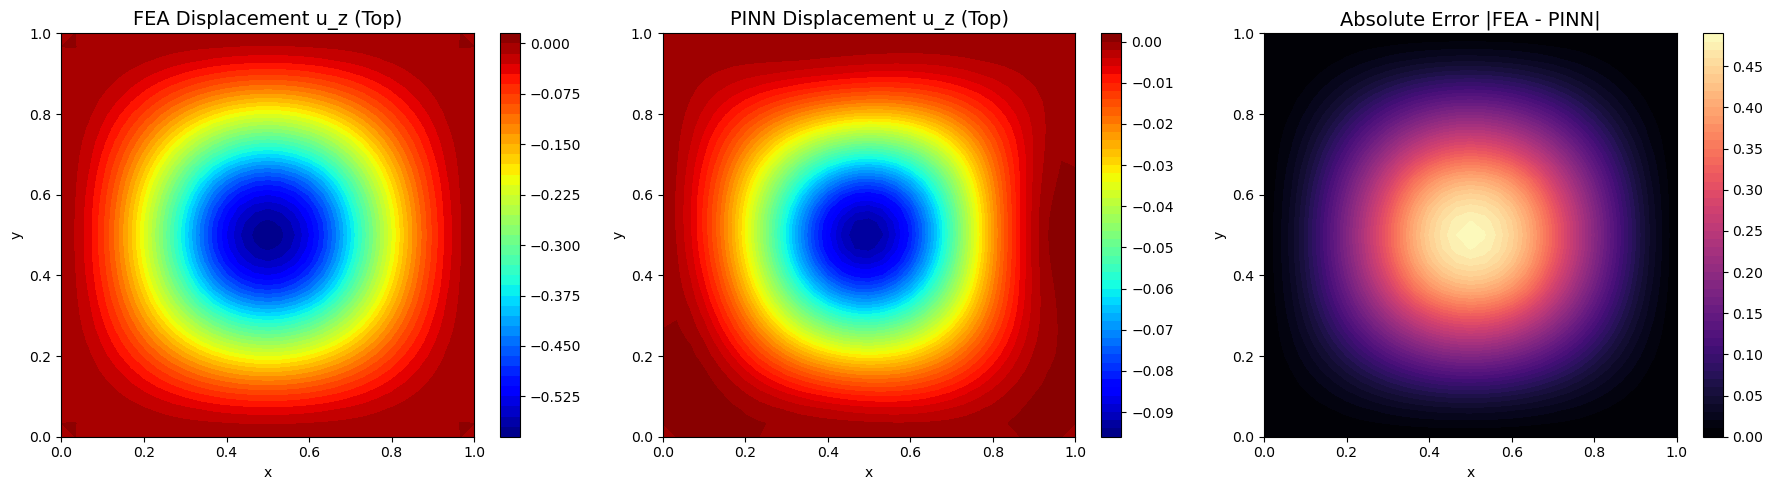

In [9]:
# Visualize comparison - Top surface
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# FEA
c1 = axes[0].contourf(X_fea[:,:,0], Y_fea[:,:,0], u_z_fea_top, levels=50, cmap='jet')
axes[0].set_title("FEA Displacement u_z (Top)", fontsize=14)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(c1, ax=axes[0])

# PINN
c2 = axes[1].contourf(X_fea[:,:,0], Y_fea[:,:,0], u_z_pinn_top, levels=50, cmap='jet')
axes[1].set_title("PINN Displacement u_z (Top)", fontsize=14)
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(c2, ax=axes[1])

# Error
c3 = axes[2].contourf(X_fea[:,:,0], Y_fea[:,:,0], abs_diff, levels=50, cmap='magma')
axes[2].set_title("Absolute Error |FEA - PINN|", fontsize=14)
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(c3, ax=axes[2])

plt.tight_layout()
plt.savefig("comparison_top.png", dpi=150)
print("Saved comparison_top.png")
plt.show()

Saved comparison_cross_section.png


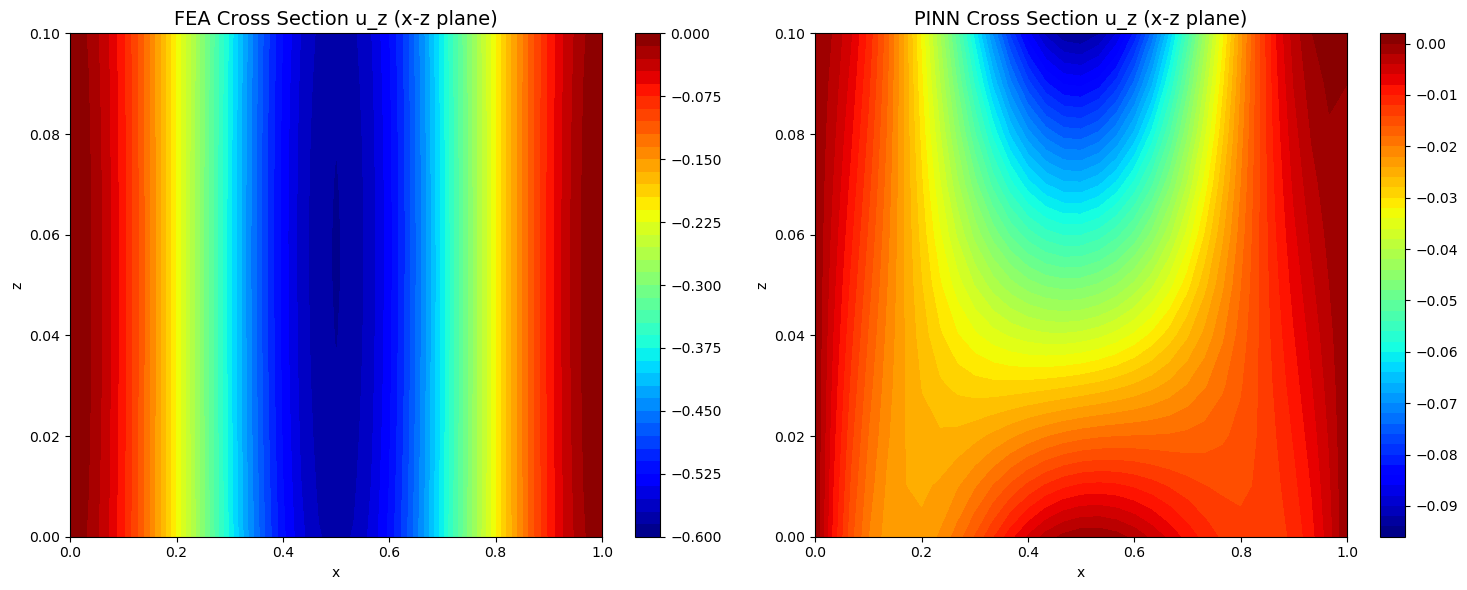

In [10]:
# Visualize cross-section (x-z plane at mid-y)
mid_y = U_fea.shape[1] // 2

xz_X = X_fea[:, mid_y, :]
xz_Z = Z_fea[:, mid_y, :]
xz_Uz_fea = U_fea[:, mid_y, :, 2]
xz_Uz_pinn = U_pinn[:, mid_y, :, 2]

fig2, axes2 = plt.subplots(1, 2, figsize=(15, 6))

c4 = axes2[0].contourf(xz_X, xz_Z, xz_Uz_fea, levels=50, cmap='jet')
axes2[0].set_title("FEA Cross Section u_z (x-z plane)", fontsize=14)
axes2[0].set_xlabel("x")
axes2[0].set_ylabel("z")
plt.colorbar(c4, ax=axes2[0])

c5 = axes2[1].contourf(xz_X, xz_Z, xz_Uz_pinn, levels=50, cmap='jet')
axes2[1].set_title("PINN Cross Section u_z (x-z plane)", fontsize=14)
axes2[1].set_xlabel("x")
axes2[1].set_ylabel("z")
plt.colorbar(c5, ax=axes2[1])

plt.tight_layout()
plt.savefig("comparison_cross_section.png", dpi=150)
print("Saved comparison_cross_section.png")
plt.show()

# Visualize PDE Residuals

Check how well the PINN satisfies the equilibrium equations.

In [11]:
# Compute PDE residual on x-z plane at mid-y
import physics

# Sample points on x-z plane
nx_res, nz_res = 50, 20
x_res = np.linspace(0, 1.0, nx_res)
z_res = np.linspace(0, 0.1, nz_res)
y_mid = 0.5

X_res, Z_res = np.meshgrid(x_res, z_res, indexing='ij')
Y_res = np.ones_like(X_res) * y_mid

pts_res = np.stack([X_res.ravel(), Y_res.ravel(), Z_res.ravel()], axis=1)
pts_res_tensor = torch.tensor(pts_res, dtype=torch.float32, requires_grad=True).to(device)

# Get Lame parameters
lm, mu = config.Lame_Params[0]

# Compute displacement
u = pinn(pts_res_tensor, 0)

# Compute gradients and stress
grad_u = physics.gradient(u, pts_res_tensor)
eps = physics.strain(grad_u)
sig = physics.stress(eps, lm, mu)

# Compute divergence (PDE residual)
div_sigma = physics.divergence(sig, pts_res_tensor)
residual = -div_sigma  # Equilibrium: -div(sigma) = 0

# Convert to numpy and compute magnitude
residual_np = residual.detach().cpu().numpy()
residual_mag = np.sqrt(np.sum(residual_np**2, axis=1))
residual_mag_grid = residual_mag.reshape(X_res.shape)

print(f"PDE Residual Statistics (x-z plane):")
print(f"  Mean: {residual_mag.mean():.6e}")
print(f"  Max: {residual_mag.max():.6e}")
print(f"  Min: {residual_mag.min():.6e}")

PDE Residual Statistics (x-z plane):
  Mean: 8.981654e-02
  Max: 3.086445e-01
  Min: 4.995354e-03


Saved pde_residual_xz.png


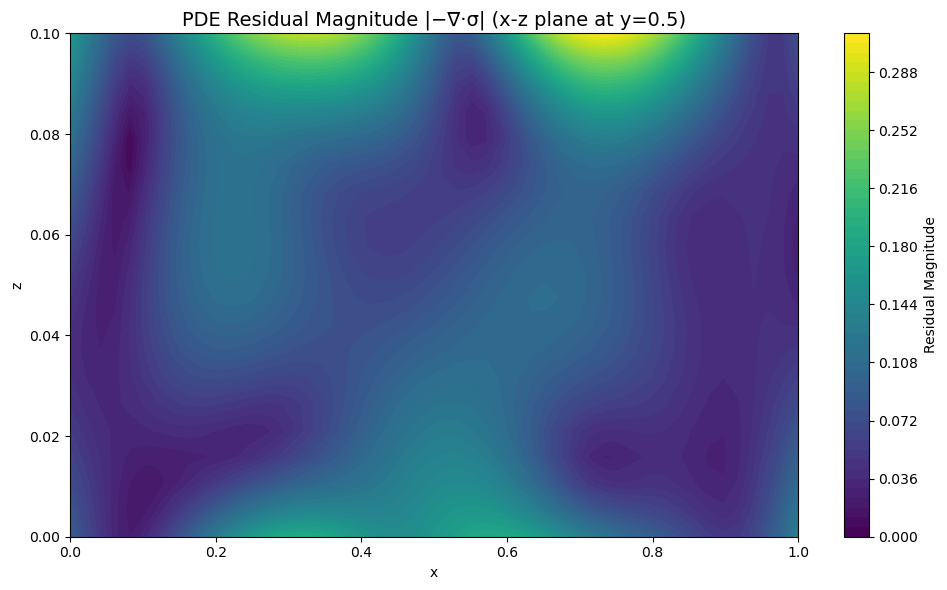

In [12]:
# Plot PDE residual magnitude
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

c = ax.contourf(X_res, Z_res, residual_mag_grid, levels=50, cmap='viridis')
ax.set_title("PDE Residual Magnitude |−∇·σ| (x-z plane at y=0.5)", fontsize=14)
ax.set_xlabel("x")
ax.set_ylabel("z")
cbar = plt.colorbar(c, ax=ax)
cbar.set_label("Residual Magnitude")

plt.tight_layout()
plt.savefig("pde_residual_xz.png", dpi=150)
print("Saved pde_residual_xz.png")
plt.show()

Saved pde_residual_components_xz.png


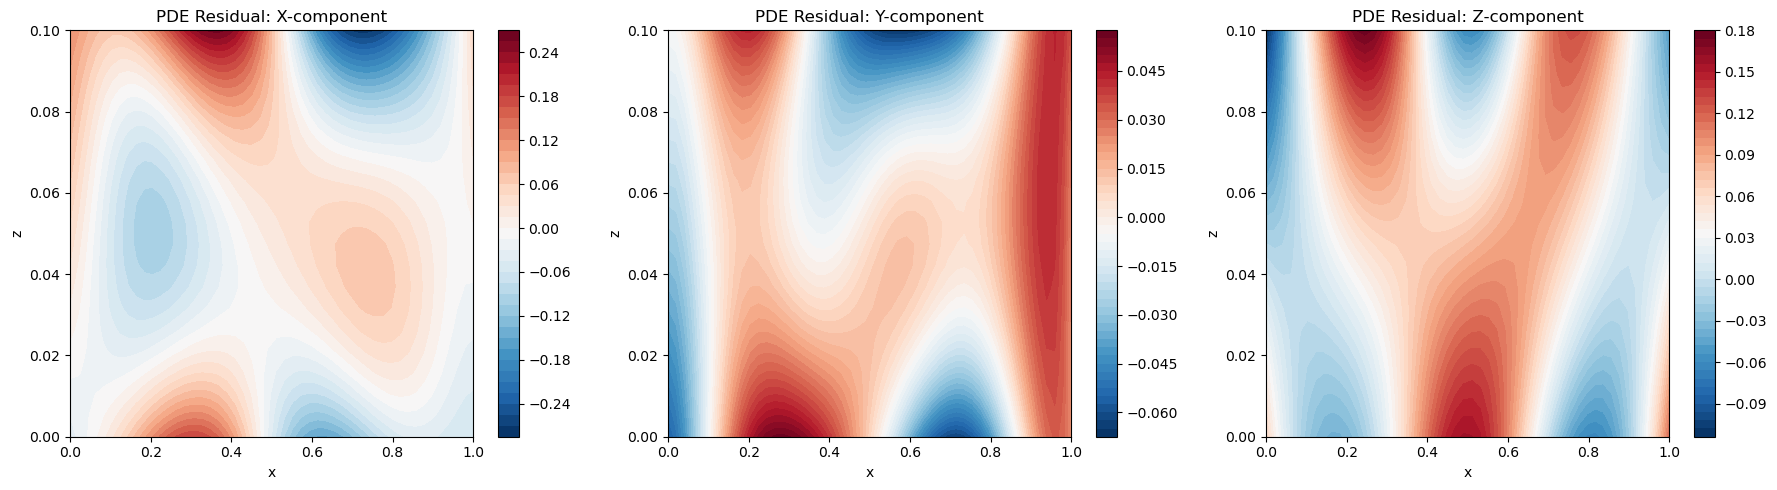

In [13]:
# Plot individual components of PDE residual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

residual_x = residual_np[:, 0].reshape(X_res.shape)
residual_y = residual_np[:, 1].reshape(X_res.shape)
residual_z = residual_np[:, 2].reshape(X_res.shape)

# X-component
c1 = axes[0].contourf(X_res, Z_res, residual_x, levels=50, cmap='RdBu_r')
axes[0].set_title("PDE Residual: X-component", fontsize=12)
axes[0].set_xlabel("x")
axes[0].set_ylabel("z")
plt.colorbar(c1, ax=axes[0])

# Y-component
c2 = axes[1].contourf(X_res, Z_res, residual_y, levels=50, cmap='RdBu_r')
axes[1].set_title("PDE Residual: Y-component", fontsize=12)
axes[1].set_xlabel("x")
axes[1].set_ylabel("z")
plt.colorbar(c2, ax=axes[1])

# Z-component
c3 = axes[2].contourf(X_res, Z_res, residual_z, levels=50, cmap='RdBu_r')
axes[2].set_title("PDE Residual: Z-component", fontsize=12)
axes[2].set_xlabel("x")
axes[2].set_ylabel("z")
plt.colorbar(c3, ax=axes[2])

plt.tight_layout()
plt.savefig("pde_residual_components_xz.png", dpi=150)
print("Saved pde_residual_components_xz.png")
plt.show()

# Visualize Traction (σ·n) on Top and Bottom Surfaces

Check boundary condition enforcement on free surfaces.

In [14]:
# Compute traction on top surface (z=H)
nx_surf, ny_surf = 50, 50
x_surf = np.linspace(0, 1.0, nx_surf)
y_surf = np.linspace(0, 1.0, ny_surf)

X_top, Y_top = np.meshgrid(x_surf, y_surf, indexing='ij')
Z_top = np.ones_like(X_top) * 0.1  # z = H

pts_top = np.stack([X_top.ravel(), Y_top.ravel(), Z_top.ravel()], axis=1)
pts_top_tensor = torch.tensor(pts_top, dtype=torch.float32, requires_grad=True).to(device)

# Compute displacement and stress on top
u_top = pinn(pts_top_tensor, 0)
grad_u_top = physics.gradient(u_top, pts_top_tensor)
eps_top = physics.strain(grad_u_top)
sig_top = physics.stress(eps_top, lm, mu)

# Traction: T = sigma · n, where n = [0, 0, 1] for top
# T = [sigma_xz, sigma_yz, sigma_zz]
T_top = sig_top[:, :, 2].detach().cpu().numpy()
T_top_x = T_top[:, 0].reshape(X_top.shape)
T_top_y = T_top[:, 1].reshape(X_top.shape)
T_top_z = T_top[:, 2].reshape(X_top.shape)

print(f"\nTop Surface Traction Statistics:")
print(f"  T_x - Mean: {T_top[:, 0].mean():.6e}, Max: {np.abs(T_top[:, 0]).max():.6e}")
print(f"  T_y - Mean: {T_top[:, 1].mean():.6e}, Max: {np.abs(T_top[:, 1]).max():.6e}")
print(f"  T_z - Mean: {T_top[:, 2].mean():.6e}, Max: {np.abs(T_top[:, 2]).max():.6e}")
print(f"  (Expected: T_x=0, T_y=0, T_z=-1.0 on load patch, T_z=0 elsewhere)")


Top Surface Traction Statistics:
  T_x - Mean: -1.115449e-03, Max: 7.100549e-02
  T_y - Mean: 5.016147e-03, Max: 7.593512e-02
  T_z - Mean: -1.342011e-01, Max: 1.060228e+00
  (Expected: T_x=0, T_y=0, T_z=-1.0 on load patch, T_z=0 elsewhere)


In [15]:
# Compute traction on bottom surface (z=0)
Z_bot = np.zeros_like(X_top)  # z = 0

pts_bot = np.stack([X_top.ravel(), Y_top.ravel(), Z_bot.ravel()], axis=1)
pts_bot_tensor = torch.tensor(pts_bot, dtype=torch.float32, requires_grad=True).to(device)

# Compute displacement and stress on bottom
u_bot = pinn(pts_bot_tensor, 0)
grad_u_bot = physics.gradient(u_bot, pts_bot_tensor)
eps_bot = physics.strain(grad_u_bot)
sig_bot = physics.stress(eps_bot, lm, mu)

# Traction: T = sigma · n, where n = [0, 0, -1] for bottom
# T = -[sigma_xz, sigma_yz, sigma_zz]
T_bot = -sig_bot[:, :, 2].detach().cpu().numpy()
T_bot_x = T_bot[:, 0].reshape(X_top.shape)
T_bot_y = T_bot[:, 1].reshape(X_top.shape)
T_bot_z = T_bot[:, 2].reshape(X_top.shape)

print(f"\nBottom Surface Traction Statistics:")
print(f"  T_x - Mean: {T_bot[:, 0].mean():.6e}, Max: {np.abs(T_bot[:, 0]).max():.6e}")
print(f"  T_y - Mean: {T_bot[:, 1].mean():.6e}, Max: {np.abs(T_bot[:, 1]).max():.6e}")
print(f"  T_z - Mean: {T_bot[:, 2].mean():.6e}, Max: {np.abs(T_bot[:, 2]).max():.6e}")
print(f"  (Expected: T_x=0, T_y=0, T_z=0)")


Bottom Surface Traction Statistics:
  T_x - Mean: 3.089141e-03, Max: 1.114395e-01
  T_y - Mean: -6.135602e-03, Max: 9.986728e-02
  T_z - Mean: 1.216754e-01, Max: 1.000356e+00
  (Expected: T_x=0, T_y=0, T_z=0)


# Debug: Check Bottom BC Loss

Verify that the bottom free surface BC is being satisfied by the trained model.

In [18]:
# Sample bottom surface points and compute BC loss as in training
import data as data_module

test_data = data_module.get_data()
x_bot_test = test_data['bottom'].to(device)
x_bot_test.requires_grad = True

u_bot_test = pinn(x_bot_test, 0)
grad_u_bot_test = physics.gradient(u_bot_test, x_bot_test)
eps_bot_test = physics.strain(grad_u_bot_test)
sig_bot_test = physics.stress(eps_bot_test, lm, mu)

# Bottom surface: n = (0, 0, -1)
# T = sigma · n = -sigma[:,:,2]
T_bot_test = -sig_bot_test[:, :, 2]

# Compute loss
loss_bot_test = torch.mean(T_bot_test**2)

print(f"\n{'='*50}")
print(f"Bottom Surface BC Violation Check:")
print(f"{'='*50}")
print(f"Bottom BC Loss (mean T²): {loss_bot_test.item():.6e}")
print(f"Mean |T|: {torch.mean(torch.abs(T_bot_test)).item():.6e}")
print(f"Max |T|: {torch.max(torch.abs(T_bot_test)).item():.6e}")
print(f"\nComponent-wise (should all be ≈0):")
print(f"  T_x: mean={T_bot_test[:, 0].mean().item():.6e}, max_abs={torch.abs(T_bot_test[:, 0]).max().item():.6e}")
print(f"  T_y: mean={T_bot_test[:, 1].mean().item():.6e}, max_abs={torch.abs(T_bot_test[:, 1]).max().item():.6e}")
print(f"  T_z: mean={T_bot_test[:, 2].mean().item():.6e}, max_abs={torch.abs(T_bot_test[:, 2]).max().item():.6e}")
print(f"{'='*50}")

# Check if there's actually pressure on bottom (should NOT be)
print(f"\nDirect σ_zz at bottom (should be ≈0 for free surface):")
print(f"  Mean σ_zz: {sig_bot_test[:, 2, 2].mean().item():.6e}")
print(f"  Max |σ_zz|: {torch.abs(sig_bot_test[:, 2, 2]).max().item():.6e}")


Bottom Surface BC Violation Check:
Bottom BC Loss (mean T²): 3.168479e-02
Mean |T|: 7.743949e-02
Max |T|: 9.969769e-01

Component-wise (should all be ≈0):
  T_x: mean=2.094078e-03, max_abs=1.105220e-01
  T_y: mean=-6.082647e-03, max_abs=9.596521e-02
  T_z: mean=1.305388e-01, max_abs=9.969769e-01

Direct σ_zz at bottom (should be ≈0 for free surface):
  Mean σ_zz: -1.305388e-01
  Max |σ_zz|: 9.969769e-01


**Analysis:**

If the bottom BC loss is high (e.g., > 1e-3) and σ_zz ≈ -1 at the bottom center, this indicates the **bottom free surface BC is not being properly enforced** during training.

Possible causes:
1. **Loss weight imbalance**: The load BC weight (5000.0) might be dominating, preventing proper bottom BC satisfaction
2. **Insufficient sampling**: Not enough collocation points on the bottom surface
3. **Training not converged**: Model hasn't learned to satisfy all BCs simultaneously
4. **Coordinate scaling**: The z-direction issue might be affecting gradient computation

The PINN may be incorrectly "mirroring" the top pressure load to the bottom, treating it symmetrically rather than enforcing the free BC.

Saved traction_top_surface.png


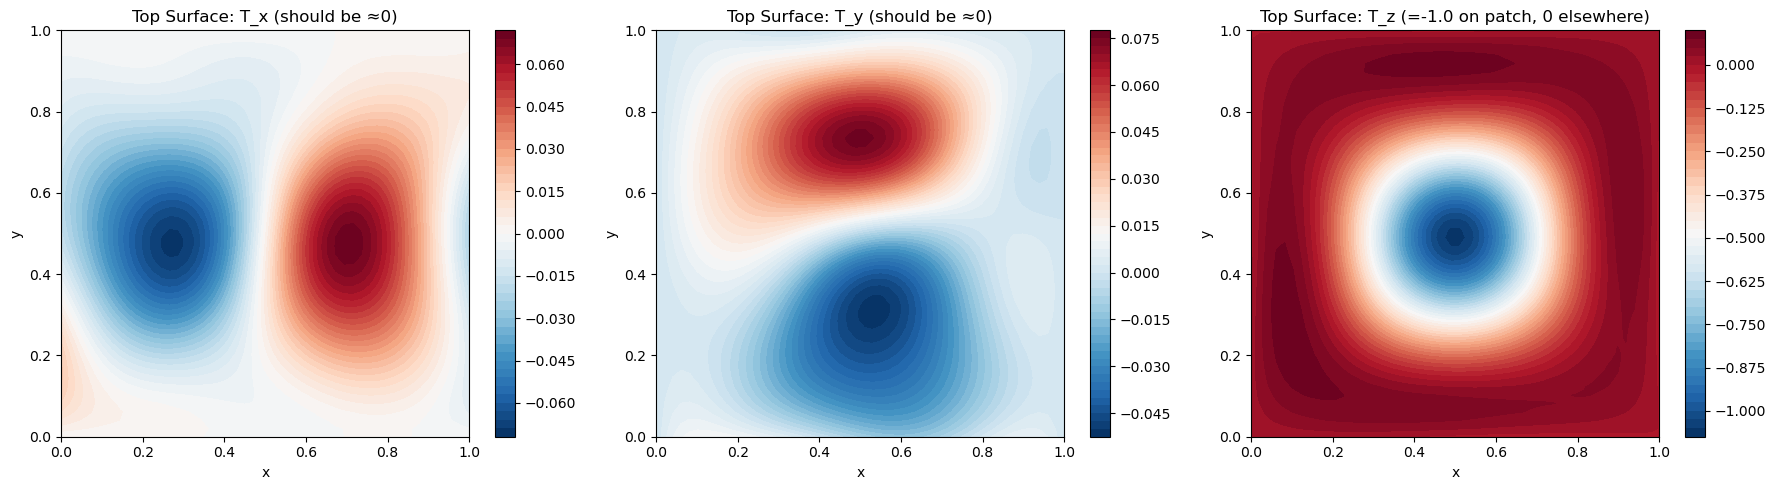

In [19]:
# Plot top surface traction components
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# T_x on top
c1 = axes[0].contourf(X_top, Y_top, T_top_x, levels=50, cmap='RdBu_r')
axes[0].set_title("Top Surface: T_x (should be ≈0)", fontsize=12)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(c1, ax=axes[0])

# T_y on top
c2 = axes[1].contourf(X_top, Y_top, T_top_y, levels=50, cmap='RdBu_r')
axes[1].set_title("Top Surface: T_y (should be ≈0)", fontsize=12)
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(c2, ax=axes[1])

# T_z on top
c3 = axes[2].contourf(X_top, Y_top, T_top_z, levels=50, cmap='RdBu_r')
axes[2].set_title("Top Surface: T_z (=-1.0 on patch, 0 elsewhere)", fontsize=12)
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(c3, ax=axes[2])

plt.tight_layout()
plt.savefig("traction_top_surface.png", dpi=150)
print("Saved traction_top_surface.png")
plt.show()

Saved traction_bottom_surface.png


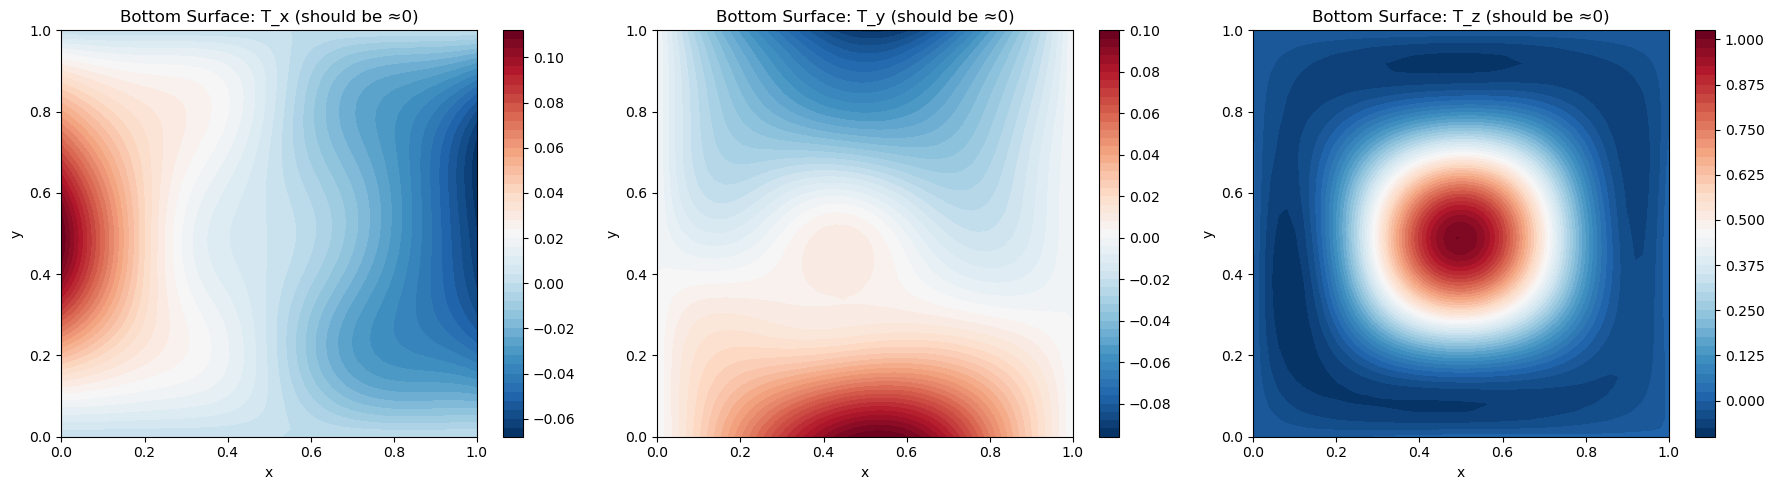

In [20]:
# Plot bottom surface traction components
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# T_x on bottom
c1 = axes[0].contourf(X_top, Y_top, T_bot_x, levels=50, cmap='RdBu_r')
axes[0].set_title("Bottom Surface: T_x (should be ≈0)", fontsize=12)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(c1, ax=axes[0])

# T_y on bottom
c2 = axes[1].contourf(X_top, Y_top, T_bot_y, levels=50, cmap='RdBu_r')
axes[1].set_title("Bottom Surface: T_y (should be ≈0)", fontsize=12)
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(c2, ax=axes[1])

# T_z on bottom
c3 = axes[2].contourf(X_top, Y_top, T_bot_z, levels=50, cmap='RdBu_r')
axes[2].set_title("Bottom Surface: T_z (should be ≈0)", fontsize=12)
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(c3, ax=axes[2])

plt.tight_layout()
plt.savefig("traction_bottom_surface.png", dpi=150)
print("Saved traction_bottom_surface.png")
plt.show()